In [1]:
# Cài đặt Kaggle API
!pip install -q kaggle

import os
import json
import zipfile
import pandas as pd

KAGGLE_USERNAME = "sangnguyentanv"
KAGGLE_KEY = "KGAT_99bf69fc5fcdfb81f164bb1ddb579587"

# Tạo thư mục .kaggle
os.makedirs("/root/.kaggle", exist_ok=True)

# Tạo file kaggle.json
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump({
        "username": KAGGLE_USERNAME,
        "key": KAGGLE_KEY
    }, f)

# Cấp quyền cho file
os.chmod("/root/.kaggle/kaggle.json", 600)

# ==========================
# Download dataset
# ==========================
!kaggle datasets download -d nudratabbas/heart-failure-readmission-and-sdoh-dataset

# Giải nén file zip
with zipfile.ZipFile(
    "heart-failure-readmission-and-sdoh-dataset.zip", "r"
) as zip_ref:
    zip_ref.extractall("dataset")

# Xem các file trong thư mục dataset
print(os.listdir("dataset"))

# ==========================
# Đọc file CSV
# ==========================

csv_file = [f for f in os.listdir("dataset") if f.endswith(".csv")][0]

df = pd.read_csv(f"dataset/{csv_file}")

# Hiển thị 5 dòng đầu
print(df.head())
print("\nShape:", df.shape)

Dataset URL: https://www.kaggle.com/datasets/nudratabbas/heart-failure-readmission-and-sdoh-dataset
License(s): CC0-1.0
100% 63.9k/63.9k [00:00<00:00, 54.8MB/s]

['heart_failure_readmission_dataset.csv']
   patient_id  age  gender   bmi  bnp  sodium  creatinine  systolic_bp  \
0       12911   76    Male  23.9  738   135.3        1.58          151   
1       12521   77    Male  32.3  405   143.0        1.50          107   
2       10155   42    Male  29.3  399     NaN        1.43          121   
3       12088   83  Female  29.1  524   135.1        0.91          114   
4       10792   48  Female  24.2  301   139.5        0.54          122   

   heart_rate  ace_inhibitor  beta_blocker  diuretic  adherence_score  \
0          93              1             1         0             0.98   
1          74              1             0         1             0.66   
2          97              1             0         1             0.93   
3          66              0             1         1       

In [2]:
# ==========================
# 1. Kiểm tra kích thước dữ liệu
# ==========================
print("Kích thước dữ liệu (hàng, cột):")
print(df.shape)

print("\nSố hàng:", df.shape[0])
print("Số cột:", df.shape[1])

# ==========================
# 2. Kiểm tra cấu trúc dữ liệu
# ==========================
print("\nThông tin các cột:")
df.info()

# ==========================
# 3. Xem 5 dòng đầu tiên và 5 dòng cuối
# ==========================
print("\n5 dòng đầu tiên:")
display(df.head())

print("\n5 dòng cuối:")
display(df.tail())

# ==========================
# 4. Thống kê mô tả cho các biến số
# ==========================
print("\nThống kê mô tả các biến số:")
display(df.describe())

# ==========================
# 5. Thống kê mô tả cho toàn bộ dữ liệu
# (bao gồm cả cột dạng chuỗi)
# ==========================
print("\nThống kê mô tả toàn bộ dữ liệu:")
display(df.describe(include='all'))

Kích thước dữ liệu (hàng, cột):
(3000, 16)

Số hàng: 3000
Số cột: 16

Thông tin các cột:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               3000 non-null   int64  
 1   age                      3000 non-null   int64  
 2   gender                   3000 non-null   object 
 3   bmi                      2910 non-null   float64
 4   bnp                      3000 non-null   int64  
 5   sodium                   2910 non-null   float64
 6   creatinine               2910 non-null   float64
 7   systolic_bp              3000 non-null   int64  
 8   heart_rate               3000 non-null   int64  
 9   ace_inhibitor            3000 non-null   int64  
 10  beta_blocker             3000 non-null   int64  
 11  diuretic                 3000 non-null   int64  
 12  adherence_score          3000 non-null   fl

,patient_id,age,gender,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,income_level,distance_to_hospital_km,readmitted_30d
0,12911,76,Male,23.9,738,135.3,1.58,151,93,1,1,0,0.98,Medium,12.4,0
1,12521,77,Male,32.3,405,143.0,1.50,107,74,1,0,1,0.66,Medium,38.8,1
2,10155,42,Male,29.3,399,NaN,1.43,121,97,1,0,1,0.93,Low,43.5,1
3,12088,83,Female,29.1,524,135.1,0.91,114,66,0,1,1,0.54,Low,33.3,1
4,10792,48,Female,24.2,301,139.5,0.54,122,79,1,1,1,0.78,High,21.3,0



5 dòng cuối:


,patient_id,age,gender,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,income_level,distance_to_hospital_km,readmitted_30d
2995,10499,85,Male,23.2,249,136.4,0.84,126,102,0,0,1,0.54,Medium,9.1,1
2996,10747,70,Male,26.1,125,139.4,0.71,135,82,0,1,1,0.57,Medium,47.6,0
2997,11948,69,Male,30.0,362,134.2,1.95,148,61,0,0,1,0.99,Medium,31.7,1
2998,12148,90,Female,26.2,503,143.6,0.16,145,56,1,1,0,0.61,Low,39.0,1
2999,12487,65,Female,24.3,456,134.3,0.99,119,116,0,0,1,0.40,Medium,48.8,1



Thống kê mô tả các biến số:


,patient_id,age,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,distance_to_hospital_km,readmitted_30d
count,3000.000000,3000.000000,2910.000000,3000.000000,2910.000000,2910.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,11499.500000,65.254333,28.109038,406.308000,138.089210,1.195082,129.588667,79.364000,0.521667,0.503333,0.489000,0.699377,25.399533,0.411333
std,866.169729,14.806465,4.949035,232.273101,4.031886,0.490563,20.257120,15.269465,0.499614,0.500072,0.499962,0.172973,14.145746,0.492157
min,10000.000000,40.000000,8.800000,50.000000,124.700000,-0.590000,61.000000,19.000000,0.000000,0.000000,0.000000,0.400000,1.000000,0.000000
25%,10749.750000,52.000000,24.800000,225.000000,135.300000,0.870000,116.000000,69.000000,0.000000,0.000000,0.000000,0.550000,12.800000,0.000000
50%,11499.500000,65.000000,28.100000,392.000000,138.100000,1.200000,130.000000,79.000000,1.000000,1.000000,0.000000,0.700000,25.450000,0.000000
75%,12249.250000,78.000000,31.500000,569.000000,140.800000,1.520000,143.000000,90.000000,1.000000,1.000000,1.000000,0.850000,37.525000,1.000000
max,12999.000000,90.000000,44.900000,1381.000000,151.600000,2.940000,196.000000,147.000000,1.000000,1.000000,1.000000,1.000000,50.000000,1.000000



Thống kê mô tả toàn bộ dữ liệu:


,patient_id,age,gender,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,income_level,distance_to_hospital_km,readmitted_30d
count,3000.000000,3000.000000,3000,2910.000000,3000.000000,2910.000000,2910.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000,3000.000000,3000.000000
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN
top,NaN,NaN,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low,NaN,NaN
freq,NaN,NaN,1508,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1024,NaN,NaN
mean,11499.500000,65.254333,NaN,28.109038,406.308000,138.089210,1.195082,129.588667,79.364000,0.521667,0.503333,0.489000,0.699377,NaN,25.399533,0.411333
std,866.169729,14.806465,NaN,4.949035,232.273101,4.031886,0.490563,20.257120,15.269465,0.499614,0.500072,0.499962,0.172973,NaN,14.145746,0.492157
min,10000.000000,40.000000,NaN,8.800000,50.000000,124.700000,-0.590000,61.000000,19.000000,0.000000,0.000000,0.000000,0.400000,NaN,1.000000,0.000000
25%,10749.750000,52.000000,NaN,24.800000,225.000000,135.300000,0.870000,116.000000,69.000000,0.000000,0.000000,0.000000,0.550000,NaN,12.800000,0.000000
50%,11499.500000,65.000000,NaN,28.100000,392.000000,138.100000,1.200000,130.000000,79.000000,1.000000,1.000000,0.000000,0.700000,NaN,25.450000,0.000000
75%,12249.250000,78.000000,NaN,31.500000,569.000000,140.800000,1.520000,143.000000,90.000000,1.000000,1.000000,1.000000,0.850000,NaN,37.525000,1.000000


In [3]:
import matplotlib.pyplot as plt

# Lấy các cột số
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Các cột số:")
print(numeric_cols)

Các cột số:
Index(['patient_id', 'age', 'bmi', 'bnp', 'sodium', 'creatinine',
       'systolic_bp', 'heart_rate', 'ace_inhibitor', 'beta_blocker',
       'diuretic', 'adherence_score', 'distance_to_hospital_km',
       'readmitted_30d'],
      dtype='object')


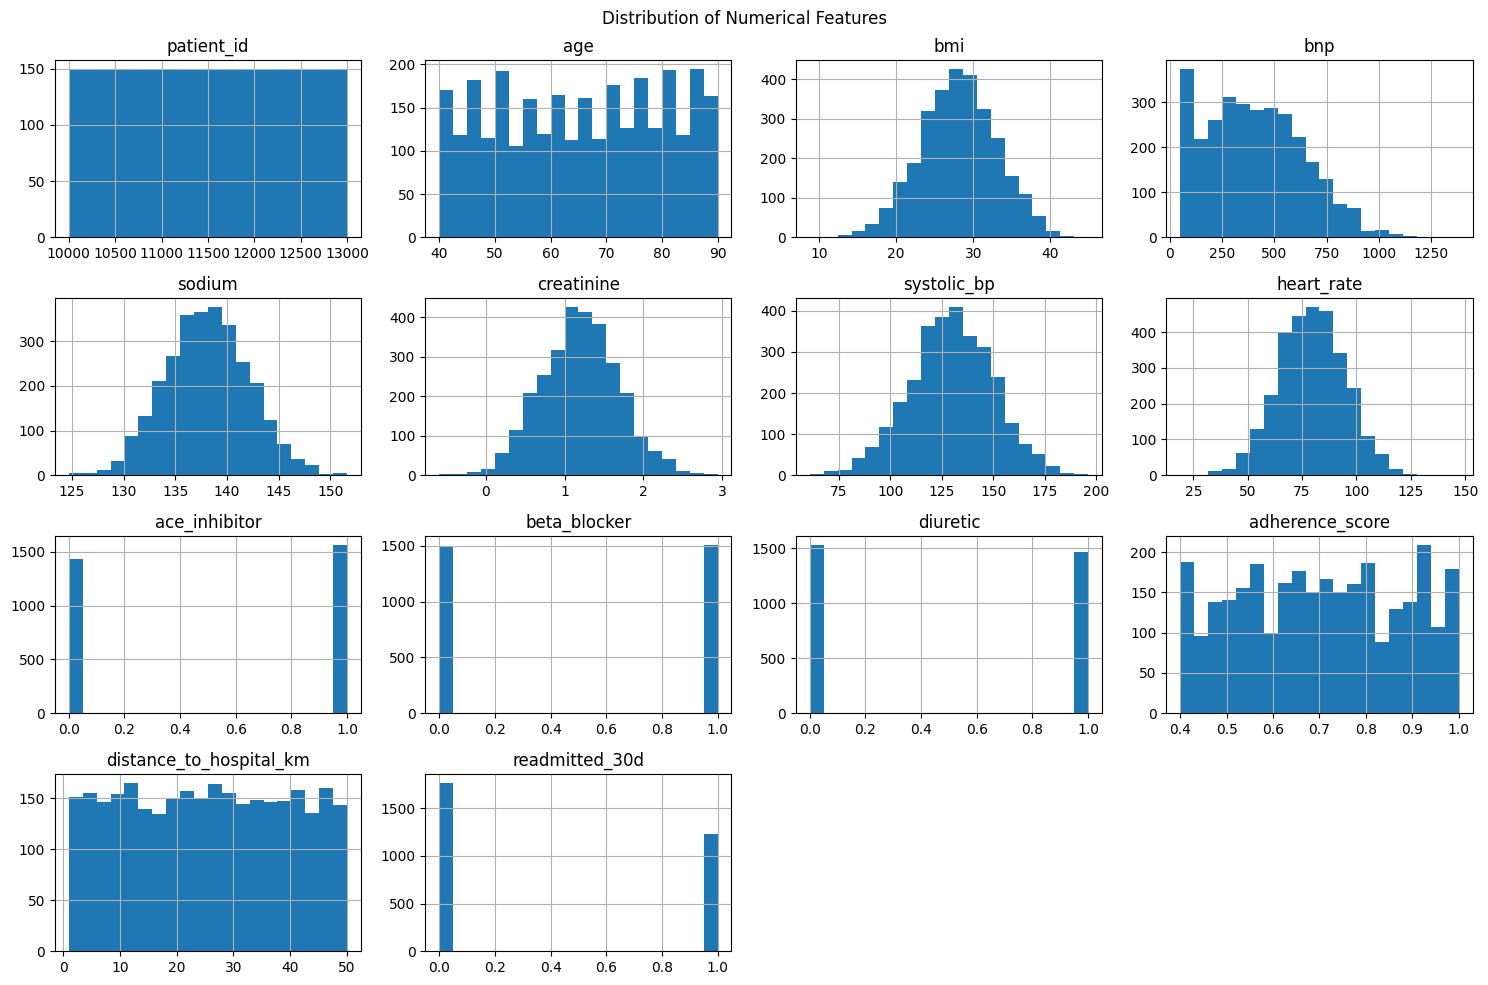

In [4]:
# Vẽ histogram cho tất cả các biến số
df[numeric_cols].hist(figsize=(15, 10), bins=20)

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ====================================================
# 1. THÔNG TIN TỔNG QUAN (General Information)
# ====================================================
print("="*60)
print("DATASET SHAPE")
print("="*60)
print(df.shape)

print("\nCOLUMN INFORMATION")
df.info()

print("\nFIRST 5 ROWS")
display(df.head())

DATASET SHAPE
(3000, 16)

COLUMN INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               3000 non-null   int64  
 1   age                      3000 non-null   int64  
 2   gender                   3000 non-null   object 
 3   bmi                      2910 non-null   float64
 4   bnp                      3000 non-null   int64  
 5   sodium                   2910 non-null   float64
 6   creatinine               2910 non-null   float64
 7   systolic_bp              3000 non-null   int64  
 8   heart_rate               3000 non-null   int64  
 9   ace_inhibitor            3000 non-null   int64  
 10  beta_blocker             3000 non-null   int64  
 11  diuretic                 3000 non-null   int64  
 12  adherence_score          3000 non-null   float64
 13  income_level             3000 non

,patient_id,age,gender,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,income_level,distance_to_hospital_km,readmitted_30d
0,12911,76,Male,23.9,738,135.3,1.58,151,93,1,1,0,0.98,Medium,12.4,0
1,12521,77,Male,32.3,405,143.0,1.50,107,74,1,0,1,0.66,Medium,38.8,1
2,10155,42,Male,29.3,399,NaN,1.43,121,97,1,0,1,0.93,Low,43.5,1
3,12088,83,Female,29.1,524,135.1,0.91,114,66,0,1,1,0.54,Low,33.3,1
4,10792,48,Female,24.2,301,139.5,0.54,122,79,1,1,1,0.78,High,21.3,0


In [6]:
# ====================================================
# 2. GIÁ TRỊ THIẾU (Missing Values)
# ====================================================
print("\nMISSING VALUES")
missing = df.isnull().sum()
display(missing[missing > 0])


MISSING VALUES


,0
bmi,90
sodium,90
creatinine,90


In [7]:
# ====================================================
# 3. DỮ LIỆU TRÙNG LẶP (Duplicate Data)
# ====================================================
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [8]:
# ====================================================
# 4. THỐNG KÊ MÔ TẢ (Descriptive Statistics)
# ====================================================
print("\nNUMERICAL SUMMARY")
display(df.describe())

print("\nCATEGORICAL SUMMARY")
display(df.describe(include='object'))


NUMERICAL SUMMARY


,patient_id,age,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,distance_to_hospital_km,readmitted_30d
count,3000.000000,3000.000000,2910.000000,3000.000000,2910.000000,2910.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,11499.500000,65.254333,28.109038,406.308000,138.089210,1.195082,129.588667,79.364000,0.521667,0.503333,0.489000,0.699377,25.399533,0.411333
std,866.169729,14.806465,4.949035,232.273101,4.031886,0.490563,20.257120,15.269465,0.499614,0.500072,0.499962,0.172973,14.145746,0.492157
min,10000.000000,40.000000,8.800000,50.000000,124.700000,-0.590000,61.000000,19.000000,0.000000,0.000000,0.000000,0.400000,1.000000,0.000000
25%,10749.750000,52.000000,24.800000,225.000000,135.300000,0.870000,116.000000,69.000000,0.000000,0.000000,0.000000,0.550000,12.800000,0.000000
50%,11499.500000,65.000000,28.100000,392.000000,138.100000,1.200000,130.000000,79.000000,1.000000,1.000000,0.000000,0.700000,25.450000,0.000000
75%,12249.250000,78.000000,31.500000,569.000000,140.800000,1.520000,143.000000,90.000000,1.000000,1.000000,1.000000,0.850000,37.525000,1.000000
max,12999.000000,90.000000,44.900000,1381.000000,151.600000,2.940000,196.000000,147.000000,1.000000,1.000000,1.000000,1.000000,50.000000,1.000000



CATEGORICAL SUMMARY


,gender,income_level
count,3000,3000
unique,2,3
top,Male,Low
freq,1508,1024


In [9]:
print(df.columns.tolist())

['patient_id', 'age', 'gender', 'bmi', 'bnp', 'sodium', 'creatinine', 'systolic_bp', 'heart_rate', 'ace_inhibitor', 'beta_blocker', 'diuretic', 'adherence_score', 'income_level', 'distance_to_hospital_km', 'readmitted_30d']



30-DAY READMISSION DISTRIBUTION


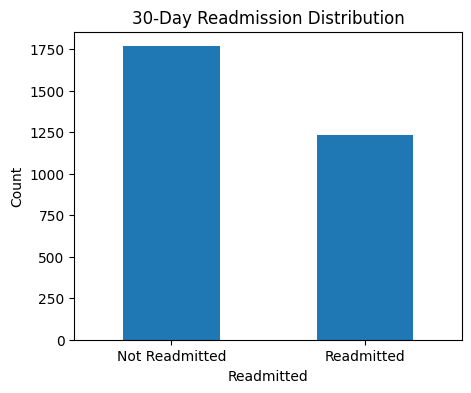

In [10]:
# ====================================================
# 6. PHÂN BỐ READMISSION (Readmission Distribution)
# ====================================================
print("\n30-DAY READMISSION DISTRIBUTION")
plt.figure(figsize=(5,4))
df['readmitted_30d'].value_counts().plot(kind='bar')
plt.title('30-Day Readmission Distribution')
plt.xlabel('Readmitted')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Not Readmitted', 'Readmitted'], rotation=0)
plt.show()


GENDER DISTRIBUTION


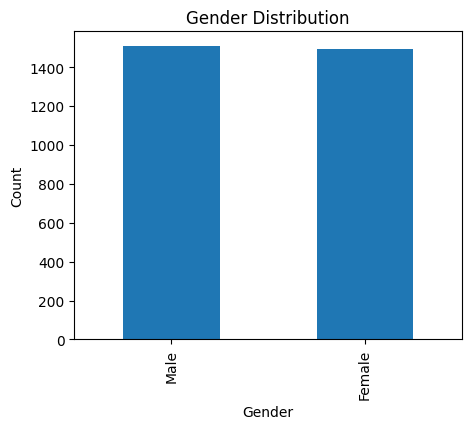

In [11]:
# ====================================================
# 7. PHÂN BỐ GIỚI TÍNH (Gender Distribution)
# ====================================================
print("\nGENDER DISTRIBUTION")
plt.figure(figsize=(5,4))
df['gender'].value_counts().plot(kind='bar')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()


INCOME LEVEL DISTRIBUTION


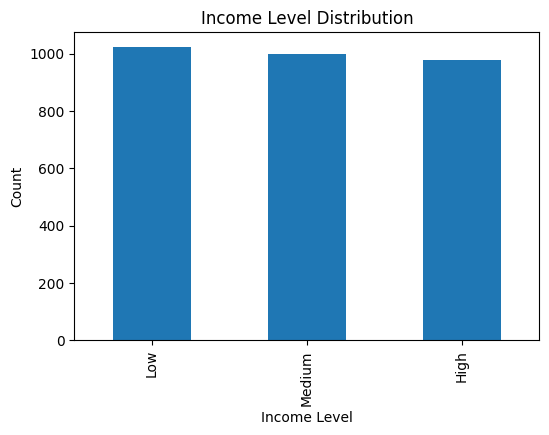

In [12]:
# ====================================================
# 8. MỨC THU NHẬP (Income Level Distribution)
# ====================================================
print("\nINCOME LEVEL DISTRIBUTION")
plt.figure(figsize=(6,4))
df['income_level'].value_counts().plot(kind='bar')
plt.title('Income Level Distribution')
plt.xlabel('Income Level')
plt.ylabel('Count')
plt.show()


BOXPLOTS FOR OUTLIER DETECTION


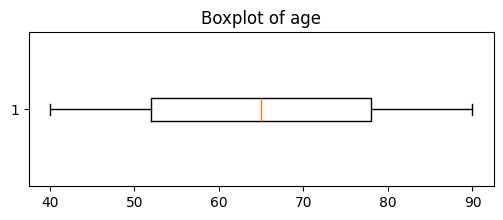

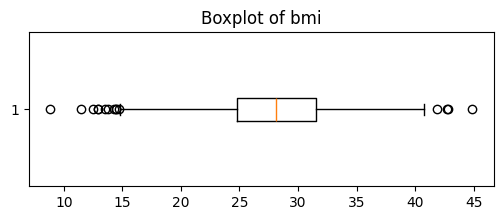

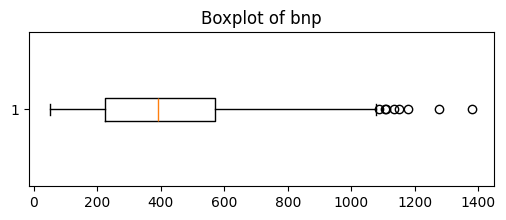

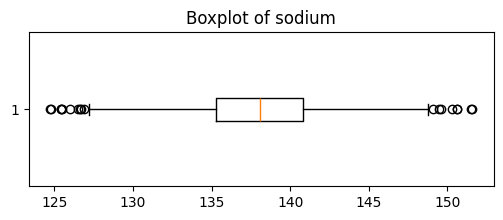

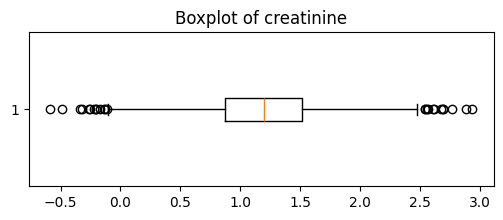

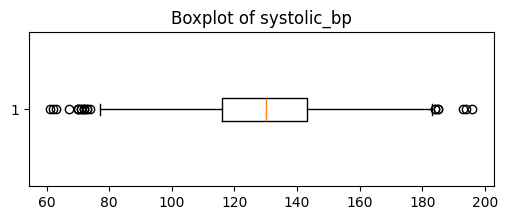

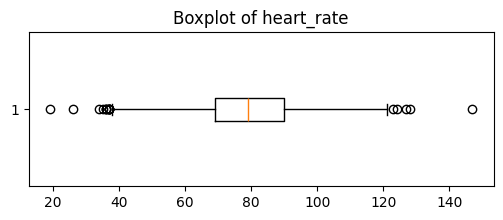

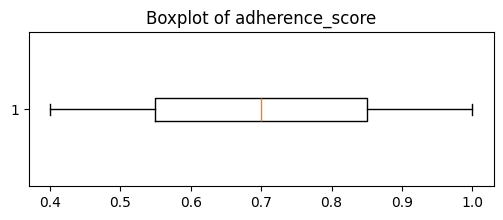

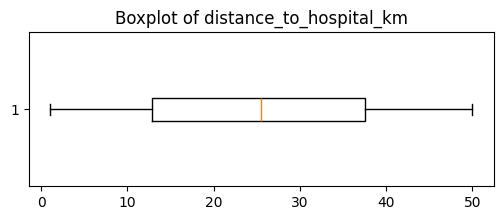

In [13]:
# ====================================================
# 9. BOXPLOT PHÁT HIỆN OUTLIER (Boxplots for Outlier Detection)
# ====================================================
print("\nBOXPLOTS FOR OUTLIER DETECTION")
numeric_cols_for_boxplot = [
    'age',
    'bmi',
    'bnp',
    'sodium',
    'creatinine',
    'systolic_bp',
    'heart_rate',
    'adherence_score',
    'distance_to_hospital_km'
]
for col in numeric_cols_for_boxplot:
    plt.figure(figsize=(6,2))
    plt.boxplot(df[col].dropna(), vert=False) # Drop NA for plotting
    plt.title(f'Boxplot of {col}')
    plt.show()


CORRELATION MATRIX


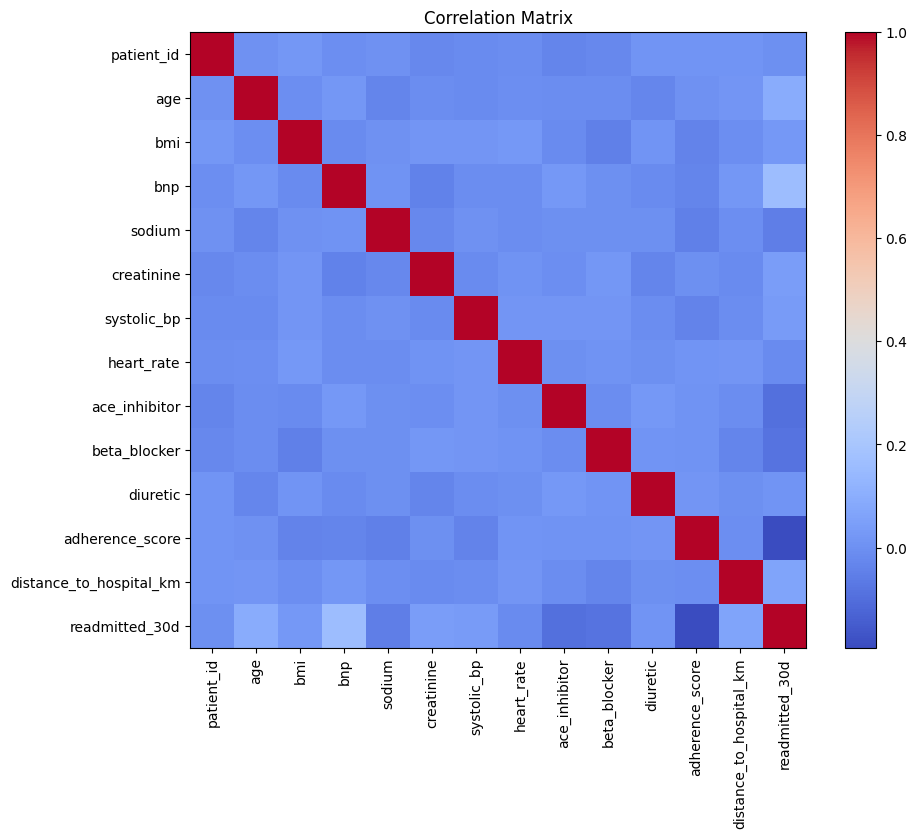

In [14]:
# ====================================================
# 10. MA TRẬN TƯƠNG QUAN (Correlation Matrix)
# ====================================================
print("\nCORRELATION MATRIX")
corr = df.select_dtypes(include=['int64', 'float64']).corr()
plt.figure(figsize=(10,8))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()


READMISSION BY GENDER


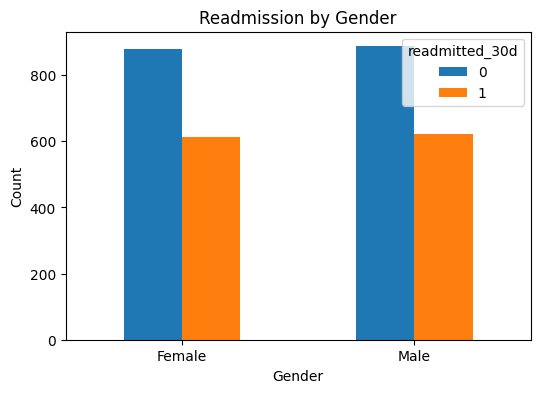

In [15]:
# ====================================================
# 11. TÁI NHẬP VIỆN THEO GIỚI TÍNH (Readmission by Gender)
# ====================================================
print("\nREADMISSION BY GENDER")
gender_readmit = pd.crosstab(df['gender'], df['readmitted_30d'])
gender_readmit.plot(kind='bar', figsize=(6,4))
plt.title("Readmission by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=gender_readmit.index, rotation=0)
plt.show()


READMISSION BY INCOME LEVEL


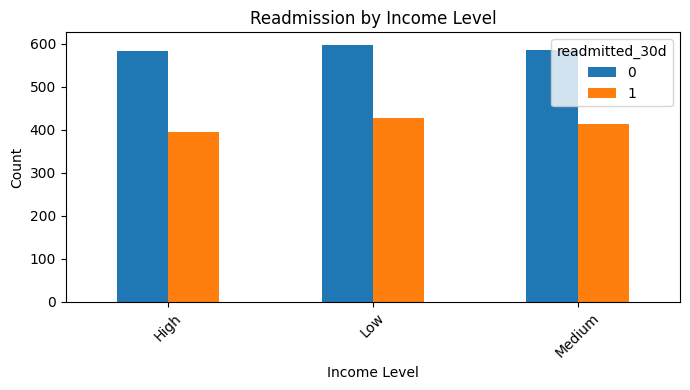


EDA COMPLETED


In [16]:
# ====================================================
# 12. TÁI NHẬP VIỆN THEO MỨC THU NHẬP (Readmission by Income Level)
# ====================================================
print("\nREADMISSION BY INCOME LEVEL")
income_readmit = pd.crosstab(df['income_level'], df['readmitted_30d'])
income_readmit.plot(kind='bar', figsize=(7,4))
plt.title("Readmission by Income Level")
plt.xlabel("Income Level")
plt.ylabel("Count")
plt.xticks(ticks=range(len(income_readmit.index)), labels=income_readmit.index, rotation=45)
plt.tight_layout()
plt.show()

print("\nEDA COMPLETED")

### Kiểm tra giá trị âm trong cột 'creatinine'

In [17]:
negative_creatinine = df[df['creatinine'] < 0]

if not negative_creatinine.empty:
    print("Các dòng có giá trị 'creatinine' < 0:")
    display(negative_creatinine)
else:
    print("Không có dòng nào có giá trị 'creatinine' < 0.")

Các dòng có giá trị 'creatinine' < 0:


,patient_id,age,gender,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,income_level,distance_to_hospital_km,readmitted_30d
40,10853,53,Male,30.1,531,138.4,-0.04,96,76,0,0,1,0.70,Low,2.5,0
192,10502,57,Male,30.0,465,143.1,-0.01,82,72,1,0,1,0.93,Medium,44.8,0
213,12805,52,Male,31.7,673,140.2,-0.34,123,77,0,0,1,0.60,Low,25.3,0
361,11941,58,Male,27.8,493,137.3,-0.49,134,93,1,0,1,0.82,Low,20.1,0
537,10639,82,Male,27.2,278,140.5,-0.59,152,66,0,1,0,0.92,Low,47.0,1
1133,10132,49,Female,32.6,486,142.0,-0.25,171,77,0,0,0,0.48,Low,2.5,0
1566,10971,50,Female,30.8,470,136.0,-0.20,130,91,1,0,0,0.69,Medium,29.3,0
1570,10854,52,Male,29.5,518,140.4,-0.13,157,68,0,1,0,0.87,High,38.4,1
1796,12314,56,Male,27.4,637,142.0,-0.26,142,80,0,0,1,0.79,Low,14.6,1
1879,12913,61,Female,31.9,569,139.9,-0.22,126,89,0,0,1,0.43,High,38.4,1


In [18]:
import numpy as np
# Clinical Range Validation: Chuyển các giá trị sinh lý phi lý về NaN
df.loc[df['creatinine'] < 0, 'creatinine'] = np.nan
df.loc[df['heart_rate'] < 30, 'heart_rate'] = np.nan
df.loc[df['bmi'] < 12, 'bmi'] = np.nan

print("Đã xử lý các giá trị ngoài ngưỡng sinh lý (Creatinine < 0, HR < 30, BMI < 12).")

Đã xử lý các giá trị ngoài ngưỡng sinh lý (Creatinine < 0, HR < 30, BMI < 12).


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Xác định các features (X) và target (y)
X = df.drop('readmitted_30d', axis=1)
y = df['readmitted_30d']

# Tách dữ liệu thành tập huấn luyện và kiểm tra
# Sử dụng stratify=y để đảm bảo tỷ lệ của biến mục tiêu 'readmitted_30d' được giữ nguyên trong cả hai tập
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Kích thước X_train: {X_train.shape}")
print(f"Kích thước X_test: {X_test.shape}")
print(f"Kích thước y_train: {y_train.shape}")
print(f"Kích thước y_test: {y_test.shape}")

Kích thước X_train: (2400, 15)
Kích thước X_test: (600, 15)
Kích thước y_train: (2400,)
Kích thước y_test: (600,)


### Chuẩn hóa dữ liệu

In [20]:
# Xác định các cột số (numerical columns) ngoại trừ 'patient_id'
# 'patient_id' không phải là một feature để train model nên ta loại bỏ
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'patient_id' in numerical_cols:
    numerical_cols.remove('patient_id')

# Khởi tạo SimpleImputer với chiến lược median
# Imputer sẽ được fit trên X_train và transform cả X_train và X_test
imputer = SimpleImputer(strategy='median')

# Fit imputer trên dữ liệu huấn luyện và transform
X_train[numerical_cols] = imputer.fit_transform(X_train[numerical_cols])

# Transform dữ liệu kiểm tra với imputer đã fit trên tập huấn luyện
X_test[numerical_cols] = imputer.transform(X_test[numerical_cols])

print("Kiểm tra giá trị thiếu sau khi imputation cho X_train:")
display(X_train[numerical_cols].isnull().sum())

print("Kiểm tra giá trị thiếu sau khi imputation cho X_test:")
display(X_test[numerical_cols].isnull().sum())

print("\nHoàn thành imputation giá trị thiếu bằng median.")

Kiểm tra giá trị thiếu sau khi imputation cho X_train:


,0
age,0
bmi,0
bnp,0
sodium,0
creatinine,0
systolic_bp,0
heart_rate,0
ace_inhibitor,0
beta_blocker,0
diuretic,0


Kiểm tra giá trị thiếu sau khi imputation cho X_test:


,0
age,0
bmi,0
bnp,0
sodium,0
creatinine,0
systolic_bp,0
heart_rate,0
ace_inhibitor,0
beta_blocker,0
diuretic,0



Hoàn thành imputation giá trị thiếu bằng median.


### Đánh giá mức độ ảnh hưởng của Feature

Kích thước X_train sau khi OHE và loại bỏ patient_id: (2400, 15)
Kích thước X_test sau khi OHE và loại bỏ patient_id: (600, 15)


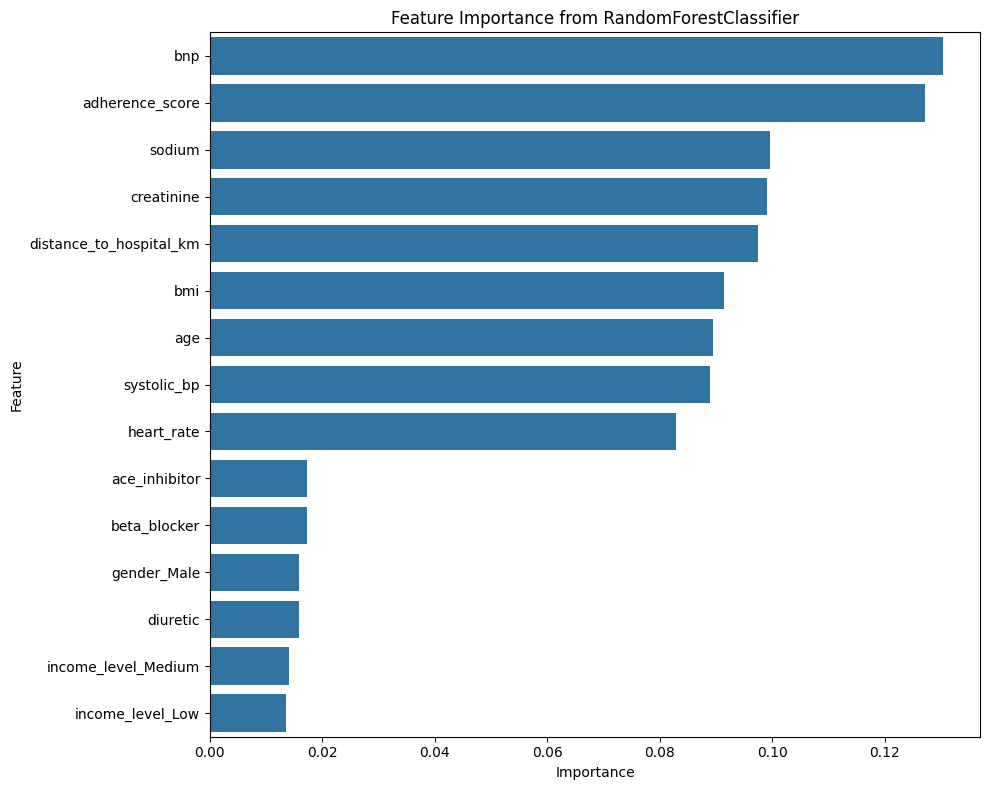

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# Identify categorical columns from the current X_train (after numerical imputation)
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

# Apply one-hot encoding using pd.get_dummies for simplicity
# This will handle creating new columns for each category and dropping original ones
X_train_ohe = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_ohe = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Drop 'patient_id' as it's an identifier, not a feature for modeling
X_train_ohe = X_train_ohe.drop(columns=['patient_id'])
X_test_ohe = X_test_ohe.drop(columns=['patient_id'])

# Align columns between X_train_ohe and X_test_ohe
# This is important in case one set has categories not present in the other after one-hot encoding
train_cols = X_train_ohe.columns
test_cols = X_test_ohe.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test_ohe[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train_ohe[c] = 0

# Ensure the order of columns is the same for both datasets
X_test_ohe = X_test_ohe[train_cols]

print("Kích thước X_train sau khi OHE và loại bỏ patient_id:", X_train_ohe.shape)
print("Kích thước X_test sau khi OHE và loại bỏ patient_id:", X_test_ohe.shape)

# Train a RandomForestClassifier to get feature importances
model = RandomForestClassifier(random_state=42)
model.fit(X_train_ohe, y_train)

# Get feature importances
feature_importances = pd.Series(model.feature_importances_, index=X_train_ohe.columns)

# Sort and plot feature importances
plt.figure(figsize=(10, 8))
sns.barplot(x=feature_importances.sort_values(ascending=False), y=feature_importances.sort_values(ascending=False).index)
plt.title('Feature Importance from RandomForestClassifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Lựa chọn Feature (Feature Selection)

In [22]:
# Lọc các feature ảnh hưởng thấp nhưng KHÔNG xóa các thuốc GDMT (ACEi, Beta-blocker, Diuretic)
gdmt_features = ['ace_inhibitor', 'beta_blocker', 'diuretic']
importance_threshold = 0.02

# Xác định các feature thấp mà không nằm trong nhóm GDMT
low_importance_features = [
    f for f in feature_importances[feature_importances < importance_threshold].index
    if f not in gdmt_features
]

print(f"Các feature bị loại bỏ: {low_importance_features}")
print(f"Các thuốc GDMT được giữ lại: {gdmt_features}")

# Loại bỏ các feature có ảnh hưởng thấp khỏi X_train_ohe và X_test_ohe
X_train_ohe = X_train_ohe.drop(columns=low_importance_features, errors='ignore')
X_test_ohe = X_test_ohe.drop(columns=low_importance_features, errors='ignore')

print(f"\nKích thước X_train sau khi lọc (giữ GDMT): {X_train_ohe.shape}")

Các feature bị loại bỏ: ['gender_Male', 'income_level_Low', 'income_level_Medium']
Các thuốc GDMT được giữ lại: ['ace_inhibitor', 'beta_blocker', 'diuretic']

Kích thước X_train sau khi lọc (giữ GDMT): (2400, 12)


### Chuẩn hóa đặc trưng (Feature Scaling)

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Cập nhật danh sách cột sau khi lọc ở bước trước
current_feature_cols = X_train_ohe.columns

# Khởi tạo StandardScaler
scaler = StandardScaler()

# Fit và transform
X_train_scaled = scaler.fit_transform(X_train_ohe)
X_test_scaled = scaler.transform(X_test_ohe)

# Trả về định dạng DataFrame
X_train_ohe = pd.DataFrame(X_train_scaled, columns=current_feature_cols, index=X_train_ohe.index)
X_test_ohe = pd.DataFrame(X_test_scaled, columns=current_feature_cols, index=X_test_ohe.index)

# Điều chỉnh trọng số về 1:2 để tìm điểm cân bằng tốt hơn giữa Recall và Precision
custom_weights = {0: 1, 1: 2}
model_lr = LogisticRegression(class_weight=custom_weights, random_state=42, max_iter=1000)

print("Đ3 điều chỉnh trọng số lớp về 1:2 để cân bằng giợa độ nhạy và tính thực tiễn lâm sàng.")

Đ3 điều chỉnh trọng số lớp về 1:2 để cân bằng giợa độ nhạy và tính thực tiễn lâm sàng.


### Chia tập Train/Validation

In [29]:
import os
from sklearn.model_selection import train_test_split

# 1. Thực hiện chia tập Train_ohe thành Train_final và Validation (tỷ lệ 80/20)
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_ohe, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# 2. Tạo thư mục 'processed_data' nếu chưa tồn tại
os.makedirs('processed_data', exist_ok=True)

# 3. Xuất các tập dữ liệu ra file CSV
X_train_final.to_csv('processed_data/X_train_final.csv', index=False)
y_train_final.to_csv('processed_data/y_train_final.csv', index=False)
X_val.to_csv('processed_data/X_val.csv', index=False)
y_val.to_csv('processed_data/y_val.csv', index=False)
# Xuất thêm cả tập Test đã tiền xử lý
X_test_ohe.to_csv('processed_data/X_test_final.csv', index=False)
y_test.to_csv('processed_data/y_test_final.csv', index=False)

print(f"Kích thước tập Train cuối: {X_train_final.shape}")
print(f"Kích thước tập Validation: {X_val.shape}")
print("Đã xuất tất cả các file CSV vào thư mục 'processed_data'.")

Kích thước tập Train cuối: (1920, 12)
Kích thước tập Validation: (480, 12)
Đã xuất tất cả các file CSV vào thư mục 'processed_data'.


### Phân bố dữ liệu trong tập Train và Validation cuối cùng


--- Phân bố Feature trong X_train_final ---


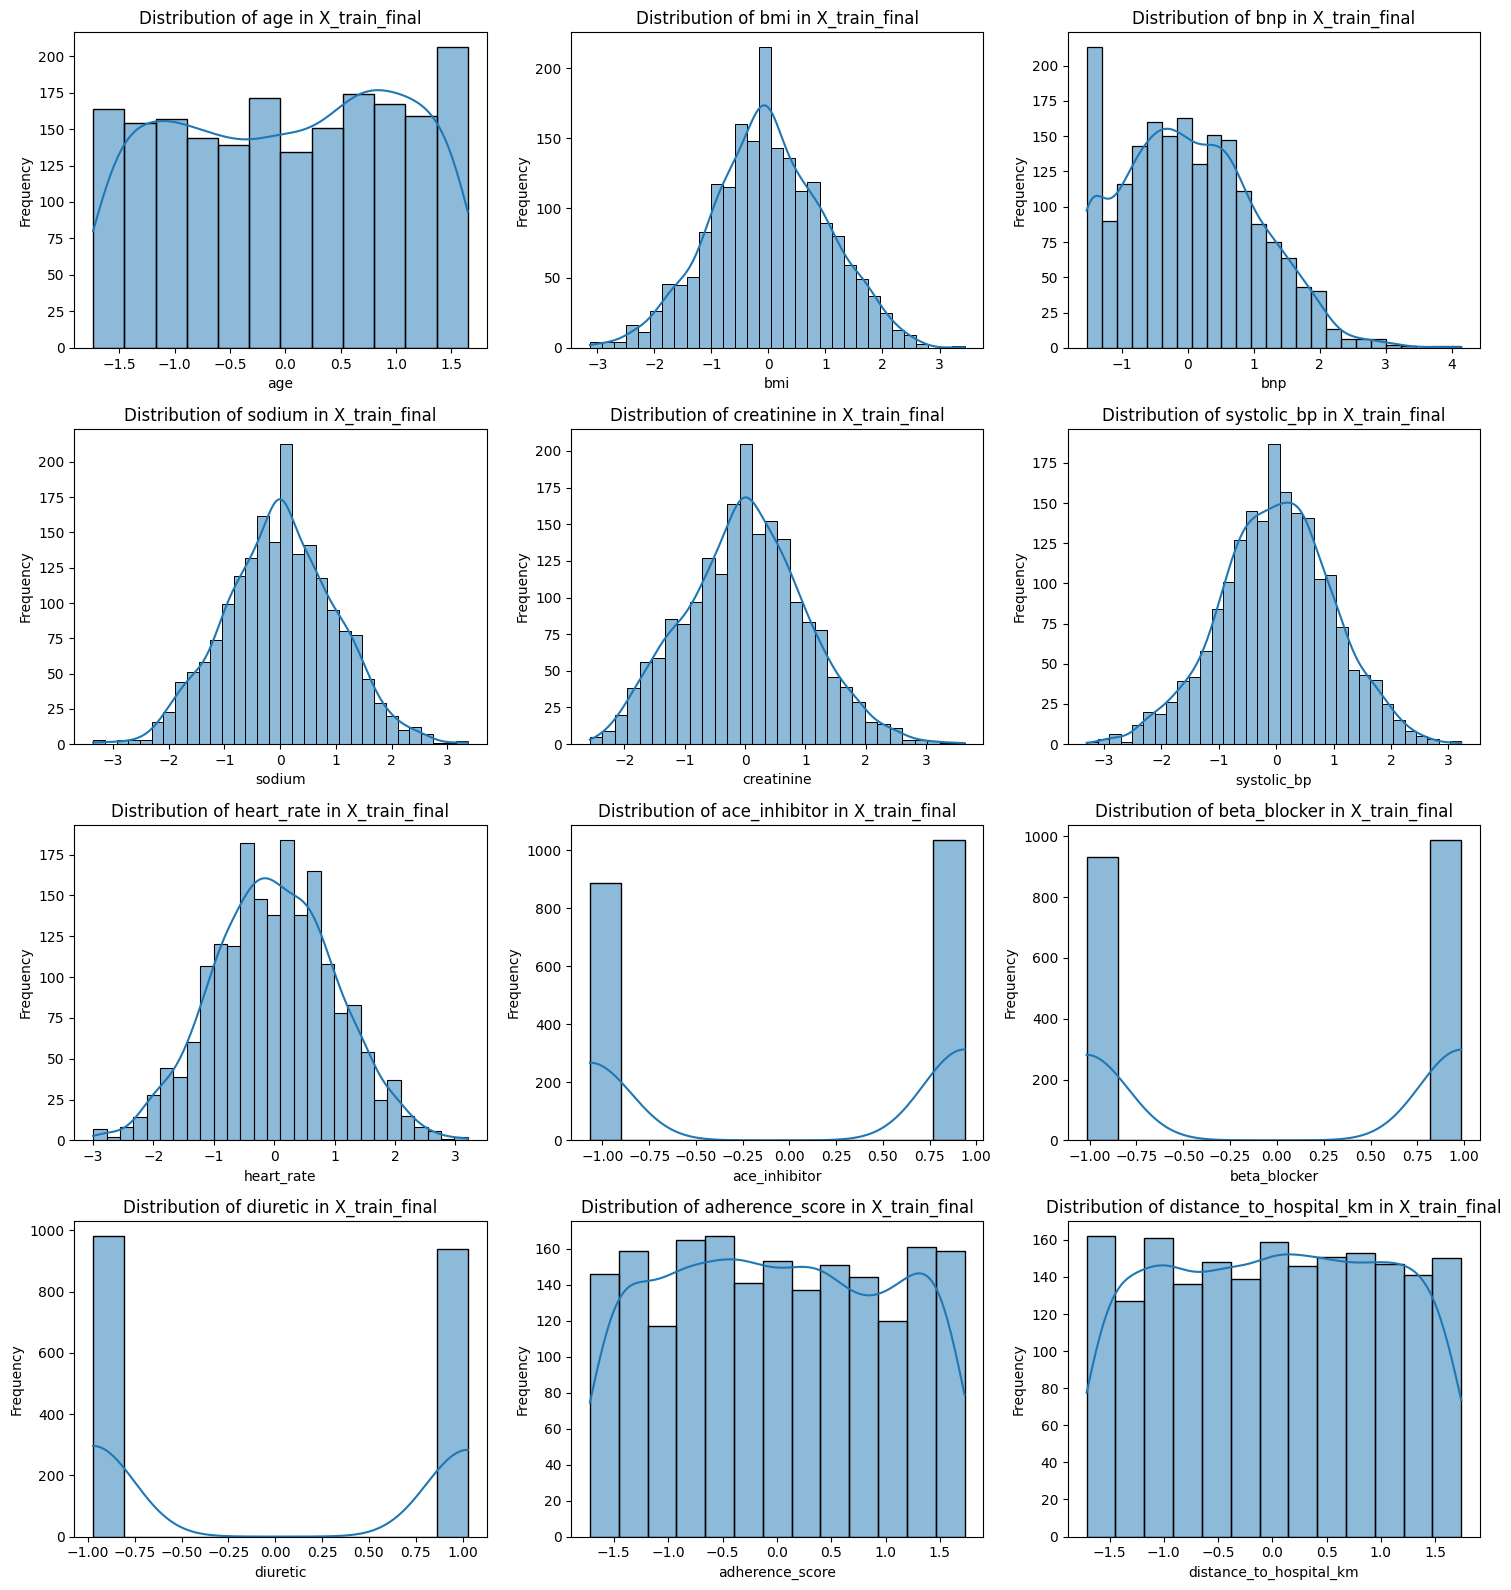


--- Phân bố Feature trong X_val ---


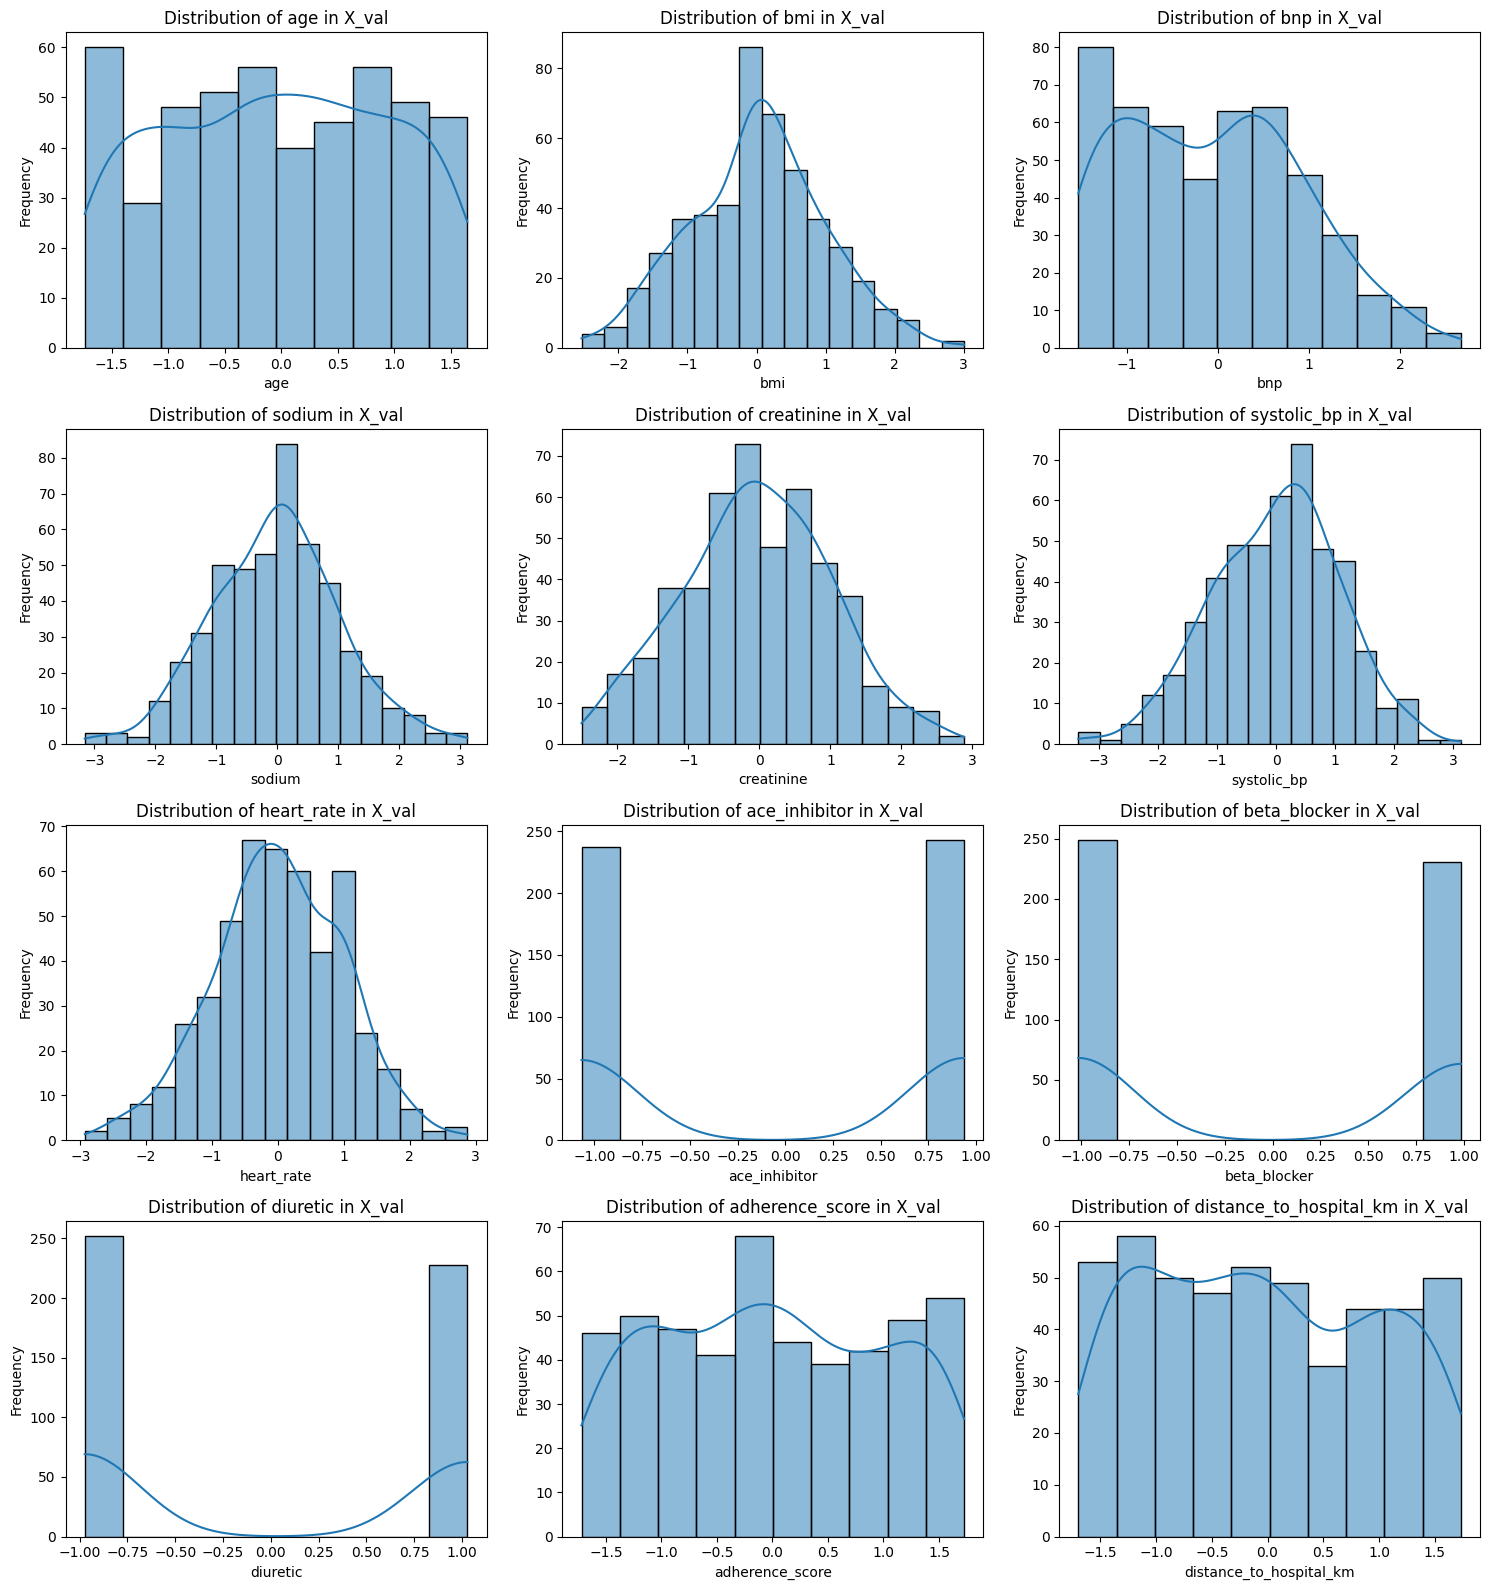

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Lấy danh sách các cột đặc trưng
numerical_cols_final = X_train_final.columns
n_cols = 3
n_rows = math.ceil(len(numerical_cols_final) / n_cols)

print("\n--- Phân bố Feature trong X_train_final ---")
plt.figure(figsize=(15, n_rows * 4))
for i, col in enumerate(numerical_cols_final):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(X_train_final[col], kde=True)
    plt.title(f'Distribution of {col} in X_train_final')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("\n--- Phân bố Feature trong X_val ---")
plt.figure(figsize=(15, n_rows * 4))
for i, col in enumerate(numerical_cols_final):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(X_val[col], kde=True)
    plt.title(f'Distribution of {col} in X_val')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Phân bố nhãn trong tập Train và Validation cuối cùng


--- Phân bố nhãn trong y_train_final ---


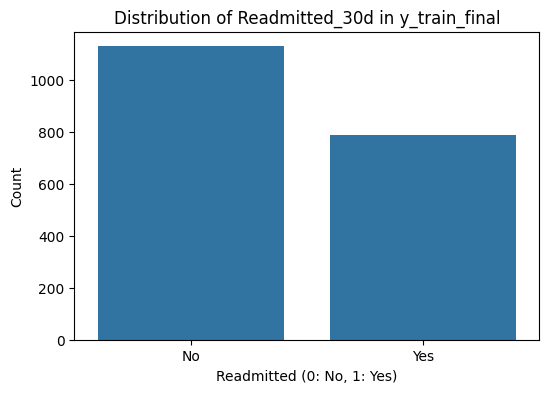


--- Phân bố nhãn trong y_val ---


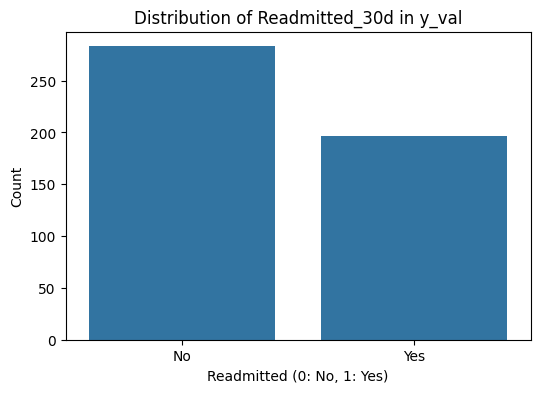

In [30]:
print('\n--- Phân bố nhãn trong y_train_final ---')
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_final)
plt.title('Distribution of Readmitted_30d in y_train_final')
plt.xlabel('Readmitted (0: No, 1: Yes)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.show()

print('\n--- Phân bố nhãn trong y_val ---')
plt.figure(figsize=(6, 4))
sns.countplot(x=y_val)
plt.title('Distribution of Readmitted_30d in y_val')
plt.xlabel('Readmitted (0: No, 1: Yes)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.show()

## Tóm tắt Pipeline Tiền Xử Lý Dữ Liệu

### 1. Tải và Khám phá dữ liệu ban đầu
*   Dữ liệu được tải từ Kaggle (`nudratabbas/heart-failure-readmission-and-sdoh-dataset`).
*   Thực hiện khám phá dữ liệu cơ bản (EDA):
    *   Kiểm tra kích thước (shape) và cấu trúc dữ liệu (`df.info()`).
    *   Hiển thị 5 dòng đầu và cuối.
    *   Thống kê mô tả cho biến số và toàn bộ dữ liệu (`df.describe()`).
    *   Phân bố các biến số số (histogram).
    *   Kiểm tra giá trị thiếu (`df.isnull().sum()`).
    *   Kiểm tra dữ liệu trùng lặp (`df.duplicated().sum()`).
    *   Phân bố biến mục tiêu (`readmitted_30d`), giới tính (`gender`), mức thu nhập (`income_level`).
    *   Boxplot để phát hiện outlier cho các biến số quan trọng.
    *   Ma trận tương quan cho các biến số.
    *   Mối quan hệ giữa tái nhập viện và giới tính/mức thu nhập.

### 2. Xử lý cột 'creatinine'
*   **Vấn đề**: Các giá trị âm trong cột 'creatinine' được phát hiện.
*   **Giải pháp**: Thay thế tất cả các giá trị 'creatinine' âm bằng `NaN` (Not a Number) để chuẩn bị cho bước xử lý giá trị thiếu tiếp theo.

### 3. Tách dữ liệu Train/Test ban đầu
*   Dữ liệu được chia thành tập huấn luyện (`X_train`, `y_train`) và tập kiểm tra (`X_test`, `y_test`) với tỷ lệ 80/20.
*   Sử dụng `stratify=y` để đảm bảo tỷ lệ của biến mục tiêu `readmitted_30d` được giữ nguyên trong cả hai tập.

### 4. Xử lý giá trị thiếu (Missing Value Imputation)
*   **Vấn đề**: Các cột 'bmi', 'sodium', 'creatinine' có giá trị thiếu (bao gồm cả `NaN` mới tạo từ bước trước).
*   **Giải pháp**: Sử dụng `SimpleImputer` với chiến lược `median` để điền vào các giá trị thiếu. Quá trình này được thực hiện riêng biệt trên `X_train` (`fit_transform`) và `X_test` (`transform`) để tránh rò rỉ dữ liệu (data leakage).
*   Đảm bảo không còn giá trị thiếu nào sau bước này.

### 5. Mã hóa One-Hot và loại bỏ Feature 'patient_id'
*   **Vấn đề**: Cần xử lý các biến phân loại và loại bỏ các định danh không cần thiết.
*   **Giải pháp**:
    *   Các cột phân loại (`gender`, `income_level`) được chuyển đổi thành các cột số bằng phương pháp One-Hot Encoding (`pd.get_dummies`).
    *   Cột 'patient_id' được loại bỏ vì nó là một định danh và không có ý nghĩa dự đoán.
    *   Căn chỉnh các cột giữa `X_train_ohe` và `X_test_ohe` để đảm bảo chúng có cùng tập hợp và thứ tự các feature.

### 6. Đánh giá và Lựa chọn Feature (Feature Selection)
*   **Mục tiêu**: Xác định và loại bỏ các feature ít quan trọng để giảm nhiễu và cải thiện hiệu suất mô hình.
*   **Giải pháp**:
    *   Huấn luyện một mô hình `RandomForestClassifier` trên `X_train_ohe` và `y_train` để tính toán mức độ quan trọng của từng feature.
    *   Trực quan hóa mức độ quan trọng của feature.
    *   **Quyết định**: Loại bỏ các feature có mức độ quan trọng dưới ngưỡng `0.02` từ cả `X_train_ohe` và `X_test_ohe`.
    *   Cập nhật `X_train_ohe` và `X_test_ohe` với tập hợp feature đã giảm.

### 7. Chia tập Train/Validation cuối cùng
*   **Mục tiêu**: Chuẩn bị dữ liệu cho quá trình huấn luyện và đánh giá mô hình nội bộ.
*   **Giải pháp**: Dữ liệu huấn luyện đã tiền xử lý (`X_train_ohe`) được chia lại thành tập huấn luyện cuối cùng (`X_train_final`, `y_train_final`) và tập validation (`X_val`, `y_val`) với tỷ lệ 80/20, sử dụng `stratify=y_train` để duy trì phân bố nhãn.

### 8. Thống kê và Xuất dữ liệu cuối cùng
*   Hiển thị kích thước và 5 dòng đầu tiên của `X_train_final`, `y_train_final`, `X_val`, `y_val`.
*   Xuất các tập dữ liệu cuối cùng (`X_train_final.csv`, `y_train_final.csv`, `X_val.csv`, `y_val.csv`) vào thư mục `processed_data` để sử dụng sau này.

### 9. Trực quan hóa Phân bố dữ liệu cuối cùng
*   **Mục tiêu**: Kiểm tra phân bố của các feature và nhãn trong các tập dữ liệu huấn luyện và validation cuối cùng.
*   **Giải pháp**:
    *   Vẽ histogram cho tất cả các feature trong `X_train_final` và `X_val`.
    *   Vẽ biểu đồ đếm (countplot) cho biến mục tiêu (`readmitted_30d`) trong `y_train_final` và `y_val` để kiểm tra sự cân bằng lớp sau khi chia.